In [3]:
# Show the Python interpreter currently used by this notebook.
import sys

print(sys.executable)

D:\BITS_Certification\intent-classifier\.venv\Scripts\python.exe


In [4]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_FILE = RAW_DATA_DIR / "Customer_Service_Training_Dataset.csv"
VALIDATION_FILE = RAW_DATA_DIR / "Customer_Service_Validation_Dataset.csv"
TEST_FILE = RAW_DATA_DIR / "Customer_Service_Testing_Dataset.csv"

In [5]:
train_df = pd.read_csv(TRAIN_FILE)
validation_df = pd.read_csv(VALIDATION_FILE)
test_df = pd.read_csv(TEST_FILE)

print("Training:", train_df.shape)
print("Validation:", validation_df.shape)
print("Testing:", test_df.shape)

Training: (6539, 4)
Validation: (818, 4)
Testing: (818, 4)


In [6]:
train_df.head(10)

,utterance,intent,category,tags
0,would it be possible to cancel the order I made?,cancel_order,ORDER,BIP
1,cancelling order,cancel_order,ORDER,BK
2,I need assistance canceling the last order I h...,cancel_order,ORDER,B
3,problem with canceling the order I made,cancel_order,ORDER,B
4,I don't know how to cancel the order I made,cancel_order,ORDER,B
5,can you help me cancel the order I made?,cancel_order,ORDER,BI
6,I would like to know about order cancellations,cancel_order,ORDER,BMP
7,could you help me cancelling an order?,cancel_order,ORDER,BIP
8,I don't know how to cancel an order I made,cancel_order,ORDER,B
9,help me cancelling my last order,cancel_order,ORDER,B


In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6539 entries, 0 to 6538
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   utterance  6539 non-null   str  
 1   intent     6539 non-null   str  
 2   category   6539 non-null   str  
 3   tags       6539 non-null   str  
dtypes: str(4)
memory usage: 204.5 KB


In [8]:
# Count how many training examples belong to each intent.
# This helps us understand whether the target classes are balanced.
intent_counts = train_df["intent"].value_counts()

# Display the count for each intent.
intent_counts

intent
get_invoice                 268
payment_issue               263
check_invoice               258
contact_customer_service    253
complaint                   252
review                      248
cancel_order                246
check_cancellation_fee      246
check_payment_methods       246
set_up_shipping_address     246
track_order                 245
place_order                 243
check_refund_policy         240
get_refund                  239
recover_password            239
registration_problems       239
track_refund                239
newsletter_subscription     238
create_account              237
delete_account              236
delivery_options            236
delivery_period             236
edit_account                233
change_order                232
change_shipping_address     228
switch_account              228
contact_human_agent         225
Name: count, dtype: int64

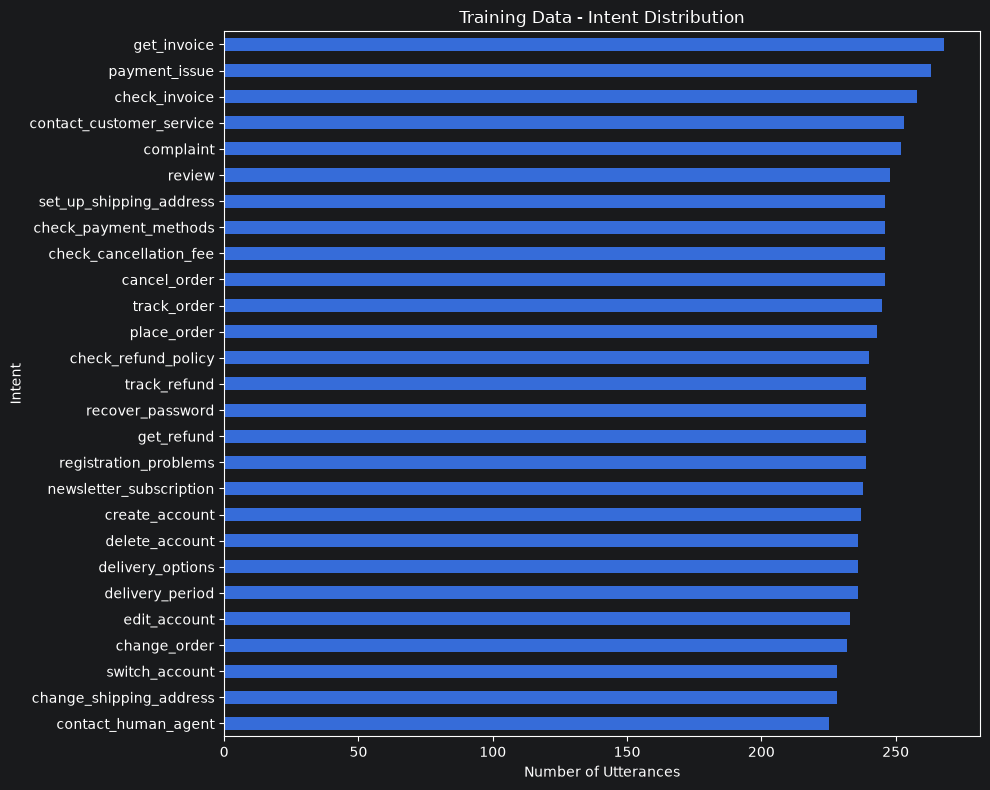

In [9]:
# Plot the number of training examples available for each intent.
# A reasonably even distribution means we are less likely to have
# serious class-imbalance problems during model training.
intent_counts.sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("Training Data - Intent Distribution")
plt.xlabel("Number of Utterances")
plt.ylabel("Intent")
plt.tight_layout()
plt.show()

In [10]:
# Count the number of training examples belonging to each
# high-level customer service category.
category_counts = train_df["category"].value_counts()

category_counts

category
ACCOUNT             1412
ORDER                966
REFUND               718
INVOICE              526
PAYMENT              509
FEEDBACK             500
CONTACT              478
SHIPPING_ADDRESS     474
DELIVERY             472
CANCELLATION_FEE     246
NEWSLETTER           238
Name: count, dtype: int64

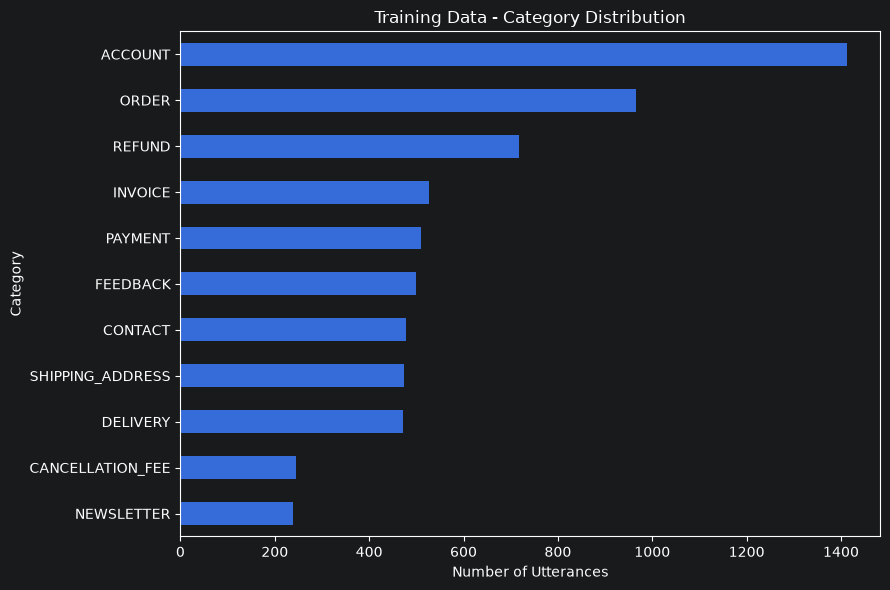

In [11]:
# Visualize the distribution of the 11 high-level categories.
category_counts.sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Training Data - Category Distribution")
plt.xlabel("Number of Utterances")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [12]:
# Find the unique category-intent combinations.
# This helps us understand how the broader 'category' column
# relates to our target variable 'intent'.
category_intent_mapping = (
    train_df[["category", "intent"]]
    .drop_duplicates()
    .sort_values(["category", "intent"])
)

category_intent_mapping

,category,intent
2426,ACCOUNT,create_account
2663,ACCOUNT,delete_account
3371,ACCOUNT,edit_account
4855,ACCOUNT,recover_password
5094,ACCOUNT,registration_problems
5827,ACCOUNT,switch_account
706,CANCELLATION_FEE,check_cancellation_fee
1948,CONTACT,contact_customer_service
2201,CONTACT,contact_human_agent
2899,DELIVERY,delivery_options


In [13]:
# Create temporary EDA columns that describe the length of each customer utterance.
# char_length counts characters, while word_count counts whitespace-separated words.
# These help us understand how short or long the customer messages typically are.

train_df["char_length"] = train_df["utterance"].str.len()

train_df["word_count"] = (
    train_df["utterance"]
    .str.split()
    .str.len()
)

# Display summary statistics for both measurements.
train_df[["char_length", "word_count"]].describe()

,char_length,word_count
count,6539.000000,6539.000000
mean,42.554366,8.318244
std,10.618668,2.404325
min,6.000000,1.000000
25%,35.000000,7.000000
50%,43.000000,8.000000
75%,51.000000,10.000000
max,60.000000,15.000000


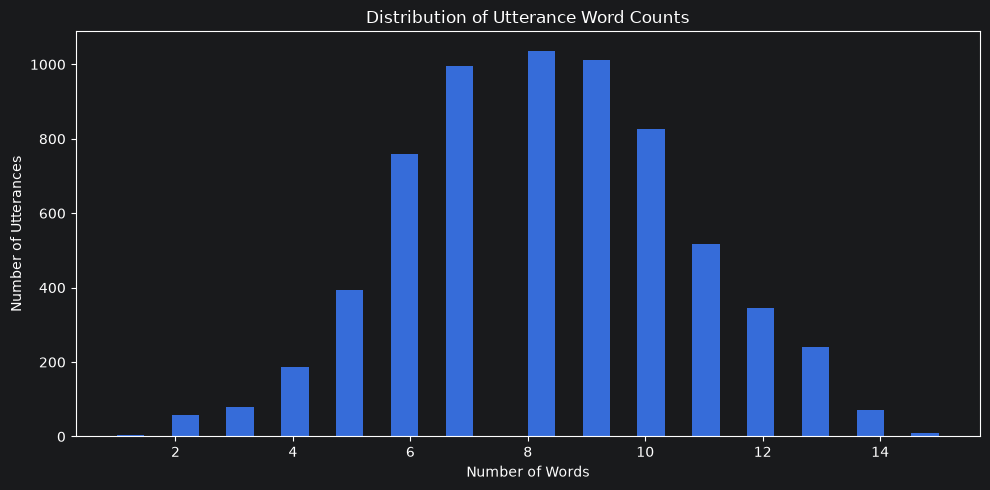

In [14]:
# Plot the distribution of customer-message lengths.
# This helps us see whether most utterances are short or whether
# there are many unusually long customer messages.

train_df["word_count"].plot(
    kind="hist",
    bins=30,
    figsize=(10, 5)
)

plt.title("Distribution of Utterance Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Utterances")
plt.tight_layout()
plt.show()

In [15]:
# Display some of the shortest utterances in the dataset.
# Very short messages can be difficult to classify because they
# may contain little information about the customer's intent.

train_df[
    ["utterance", "intent", "word_count"]
].sort_values("word_count").head(15)

,utterance,intent,word_count
2452,registering,create_account,1
1750,complaint,complaint,1
2631,register,create_account,1
5336,review,review,1
4450,payment issues,payment_issue,2
4661,making purchase,place_order,2
4406,payment help,payment_issue,2
1,cancelling order,cancel_order,2
4670,make order,place_order,2
4580,payment issue,payment_issue,2


In [16]:
# Display some of the longest utterances.
# This helps us identify unusually verbose examples and will later
# help us choose an appropriate maximum input length for transformers.

train_df[
    ["utterance", "intent", "word_count"]
].sort_values(
    "word_count",
    ascending=False
).head(15)

,utterance,intent,word_count
4748,I do not know what I have to do to buy several...,place_order,15
4713,I don't know what I need to do to buy a few of...,place_order,15
4679,I do not know what I need to do to buy several...,place_order,15
3213,I do not know how I can check how soon can I e...,delivery_period,15
2451,I do not know what I have to do to open a new ...,create_account,15
2601,i do not know what i need to do to open a new ...,create_account,15
4621,I do not know what I need to do to buy some of...,place_order,15
5933,i do not know what i have to do to switch to m...,switch_account,15
3948,I do not know what I have to do to get a refun...,get_refund,15
3977,I do not know what I need to do to get a refun...,get_refund,15


In [17]:
# Check how many utterances contain at least one uppercase character.
# This tells us whether capitalization varies across the dataset.
contains_uppercase = train_df["utterance"].str.contains(
    r"[A-Z]",
    regex=True
).sum()

# Check how many utterances are completely lowercase.
all_lowercase = train_df["utterance"].eq(
    train_df["utterance"].str.lower()
).sum()

print("Total utterances:", len(train_df))
print("Utterances containing uppercase characters:", contains_uppercase)
print("Completely lowercase utterances:", all_lowercase)

Total utterances: 6539
Utterances containing uppercase characters: 3786
Completely lowercase utterances: 2753


In [18]:
# Check how many utterances contain punctuation or other
# non-alphanumeric characters.
#
# We exclude whitespace because spaces are expected in normal sentences.

contains_special_chars = train_df["utterance"].str.contains(
    r"[^\w\s]",
    regex=True
).sum()

print(
    "Utterances containing punctuation/special characters:",
    contains_special_chars
)

Utterances containing punctuation/special characters: 2513


In [19]:
# Display examples containing punctuation/special characters.
# Looking at real examples is important before deciding whether
# punctuation should be removed during preprocessing.

train_df[
    train_df["utterance"].str.contains(r"[^\w\s]", regex=True)
][["utterance", "intent"]].head(20)

,utterance,intent
0,would it be possible to cancel the order I made?,cancel_order
4,I don't know how to cancel the order I made,cancel_order
5,can you help me cancel the order I made?,cancel_order
7,could you help me cancelling an order?,cancel_order
8,I don't know how to cancel an order I made,cancel_order
27,where can I get information about canceling or...,cancel_order
31,can you give me information about cancelling o...,cancel_order
33,I don't know how to cancel my last order,cancel_order
37,how can I find information about cancelling or...,cancel_order
41,can you help me to cancel the last order I hav...,cancel_order


In [20]:
# Check whether customer utterances contain numbers.
# Numbers can sometimes carry useful information in real support tickets,
# such as order numbers, amounts, dates or quantities.

contains_numbers = train_df["utterance"].str.contains(
    r"\d",
    regex=True
).sum()

print("Utterances containing numbers:", contains_numbers)

Utterances containing numbers: 66


Dataset Split Overlap Analysis

In [22]:
# Normalize utterances before comparing them.
# We lowercase and strip whitespace so trivial formatting differences
# do not prevent us from detecting the same text across dataset splits.

train_text = set(
    train_df["utterance"]
    .str.lower()
    .str.strip()
)

validation_text = set(
    validation_df["utterance"]
    .str.lower()
    .str.strip()
)

test_text = set(
    test_df["utterance"]
    .str.lower()
    .str.strip()
)


# Find identical utterances appearing across different dataset splits.
train_validation_overlap = train_text.intersection(validation_text)
train_test_overlap = train_text.intersection(test_text)
validation_test_overlap = validation_text.intersection(test_text)


print(
    "Training ↔ Validation exact overlap:",
    len(train_validation_overlap)
)

print(
    "Training ↔ Testing exact overlap:",
    len(train_test_overlap)
)

print(
    "Validation ↔ Testing exact overlap:",
    len(validation_test_overlap)
)

Training ↔ Validation exact overlap: 0
Training ↔ Testing exact overlap: 0
Validation ↔ Testing exact overlap: 0


## Near-Duplicate / Template Similarity Analysis

In [23]:
# ---------------------------------------------------------
# Near-Duplicate / Template Similarity Analysis
# ---------------------------------------------------------
#
# Exact overlap was 0, which tells us that identical utterances
# do not appear across the dataset splits.
#
# However, two sentences can still be extremely similar:
#
# Training:   "how can I cancel my order"
# Validation: "how do I cancel my order"
#
# We therefore measure how similar each validation utterance is
# to its MOST similar training utterance.


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# ---------------------------------------------------------
# 1. Create a TF-IDF representation
# ---------------------------------------------------------
#
# IMPORTANT:
# Fit the vectorizer only on training data.
#
# Validation data is transformed using the vocabulary learned
# from training, exactly like we do during model training.

similarity_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=5000
)

train_vectors = similarity_vectorizer.fit_transform(
    train_df["utterance"]
)

validation_vectors = similarity_vectorizer.transform(
    validation_df["utterance"]
)


# ---------------------------------------------------------
# 2. Calculate validation-to-training similarity
# ---------------------------------------------------------
#
# cosine_similarity compares every validation utterance with
# every training utterance.
#
# Shape will approximately be:
#
# 818 validation rows × 6539 training rows

similarity_matrix = cosine_similarity(
    validation_vectors,
    train_vectors
)


# ---------------------------------------------------------
# 3. Find the closest training example for every
#    validation example
# ---------------------------------------------------------

# Maximum similarity score for each validation utterance.
max_similarity_scores = similarity_matrix.max(axis=1)

# Index of the training utterance that produced that score.
closest_training_indices = similarity_matrix.argmax(axis=1)


# Store the results for easier analysis.
similarity_results = validation_df[
    ["utterance", "intent"]
].copy()

similarity_results["max_similarity"] = max_similarity_scores

similarity_results["closest_training_utterance"] = [
    train_df.iloc[index]["utterance"]
    for index in closest_training_indices
]

similarity_results["closest_training_intent"] = [
    train_df.iloc[index]["intent"]
    for index in closest_training_indices
]

In [24]:
# ---------------------------------------------------------
# 4. Summarize similarity scores
# ---------------------------------------------------------

print("Validation → Training similarity statistics:\n")

print(
    similarity_results["max_similarity"].describe()
)

Validation → Training similarity statistics:

count    818.000000
mean       0.816059
std        0.130672
min        0.311990
25%        0.746077
50%        0.859000
75%        0.912824
max        1.000000
Name: max_similarity, dtype: float64


In [25]:
# ---------------------------------------------------------
# 5. Count highly similar validation examples
# ---------------------------------------------------------

for threshold in [0.80, 0.90, 0.95]:
    count = (
        similarity_results["max_similarity"] >= threshold
    ).sum()

    percentage = (
        count / len(similarity_results)
    ) * 100

    print(
        f"Similarity >= {threshold:.2f}: "
        f"{count} examples ({percentage:.2f}%)"
    )

Similarity >= 0.80: 532 examples (65.04%)
Similarity >= 0.90: 266 examples (32.52%)
Similarity >= 0.95: 55 examples (6.72%)


In [26]:
# ---------------------------------------------------------
# 6. Inspect the most similar train-validation pairs
# ---------------------------------------------------------

most_similar_examples = (
    similarity_results
    .sort_values(
        "max_similarity",
        ascending=False
    )
    .head(15)
)

pd.set_option("display.max_colwidth", None)

most_similar_examples[
    [
        "utterance",
        "intent",
        "closest_training_utterance",
        "closest_training_intent",
        "max_similarity",
    ]
]

,utterance,intent,closest_training_utterance,closest_training_intent,max_similarity
502,I can't subscribe to your company newsletter,newsletter_subscription,can I subscribe to your company newsletter?,newsletter_subscription,1.000000
193,I can't check your money back policy,check_refund_policy,can I check your money back policy?,check_refund_policy,1.000000
96,need help checking the cancellation fees,check_cancellation_fee,I need help checking the cancellation fees,check_cancellation_fee,1.000000
205,I can't check your refund policy,check_refund_policy,can I check your refund policy?,check_refund_policy,1.000000
251,I can't talk to an agent,contact_human_agent,can I talk to an agent?,contact_human_agent,1.000000
775,can I check my order ETA?,track_order,I can't check my order ETA,track_order,1.000000
809,can I check the status of my refund?,track_refund,I can't check the status of my refund,track_refund,1.000000
167,is it possible to see what payment methods are available?,check_payment_methods,is it possible to see what payment methods are available,check_payment_methods,1.000000
701,I can't set a new shipping address up,set_up_shipping_address,can I set a new shipping address up?,set_up_shipping_address,1.000000
755,can I check the status of my order?,track_order,I can't check the status of my order,track_order,1.000000
